# Data Preprocessing

In [1]:
from src.data_preprocessing import (
    read_oscilloscope_data, 
    process_time_series,
    load_data_from_directory,
    extract_and_normalize_peak_segments,
    plot_random_segments
)

from src.utils import move_random_csv_files, rename_folder, plot_spectrum
import pandas as pd


%load_ext autoreload
%autoreload 2

## Anomalous data

<Axes: xlabel='Time'>

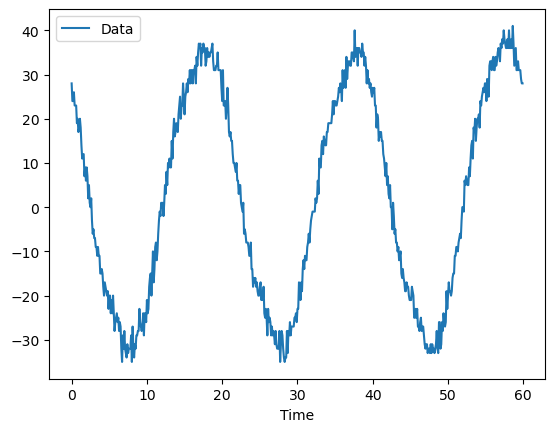

In [2]:
# Read raw data
df = read_oscilloscope_data(
    file_path='../data/raw/0702  межвитковые фазы A ток фазы А.txt',
    output_path='../data/processed/Anomalous.csv'
    )

df[:600].plot(x='Time', y='Data')

In [3]:
# Process time series
process_time_series(
    input_data=df, 
    output_dir='../data/processed/Final_Anomalous', 
    f_sampling=10000, 
    db=True
)

Results saved to ../data/processed/Final_Anomalous


In [4]:
# Load processed data
fft_data = load_data_from_directory(directory='../data/processed/Final_Anomalous')

### MCSA

In [23]:
# Generate frequencies corresponding to Inter-turn short circuit fault
from src.electrical_signature_frequencies import ANOMALY_FREQS

# Open config with parameters of the engine
import yaml

with open('../engine_configs/LIMAN.yml', 'r') as f:
    engine_config = yaml.safe_load(f)

# Filter negative frequencies
anomaly_freqs = ANOMALY_FREQS['inter-turn short circuits'](engine_config, k_values=range(1,4), m_range=range(1,4))
anomaly_freqs = [freq for freq in anomaly_freqs if freq > 0]
print(f'Anomaly Frequencies: {", ".join(map(str, anomaly_freqs))}')

Anomaly Frequencies: 3.334, 26.667, 30.001, 50.0, 53.334, 73.333, 76.667, 80.001, 96.666, 100.0, 103.334, 119.999, 123.333, 126.667, 146.666, 150.0, 169.999, 173.333, 196.666, 219.999


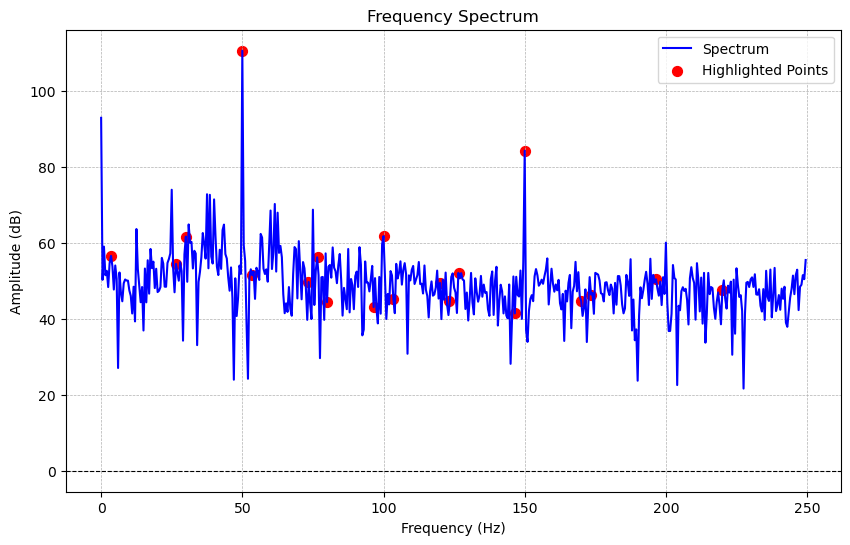

In [24]:
# Plot spectrum with highlighted fault frequencies
plot_spectrum(pd.read_csv('../data/processed/Final_Anomalous/Window_1.csv'), 
              highlight_freqs=anomaly_freqs,
              method='closest')

### Validate Peaks

In [17]:
# Extract and normalize peak segments
segment_length = 6
target_frequency = 150

normalized_peak_segments, minmax_stats = extract_and_normalize_peak_segments(
    fft_data, 
    segment_length=segment_length, 
    target_frequency=target_frequency, 
    method='min-max'
)

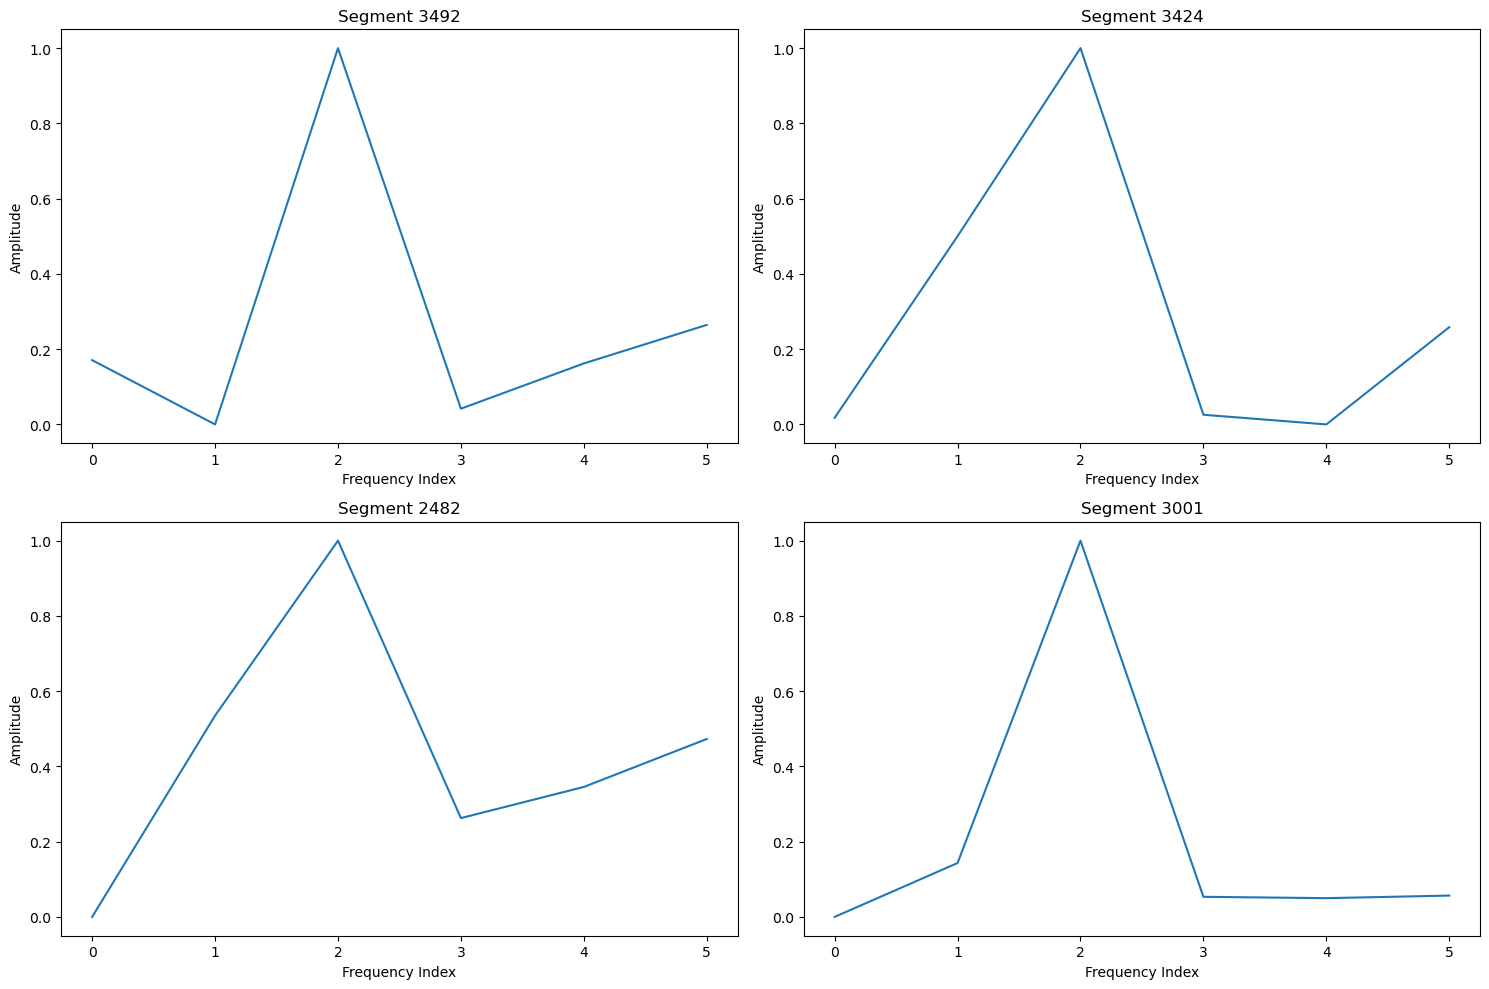

In [18]:
# Plot segments
plot_random_segments(normalized_peak_segments, num_segments=4)

## Normal and Candidates for Augmentation Data

In [8]:
# Read raw data
df = read_oscilloscope_data(
    file_path='../data/raw/0702 без перекосов фаза A.txt',
    output_path='../data/processed/Normal.csv'
    )

In [9]:
# Process time series
process_time_series(
    input_data='../data/processed/Normal.csv', 
    output_dir='../data/processed/Normal_and_Candidates_for_Augmentation', 
    f_sampling=10000, 
    db=True
)

Results saved to ../data/processed/Normal_and_Candidates_for_Augmentation


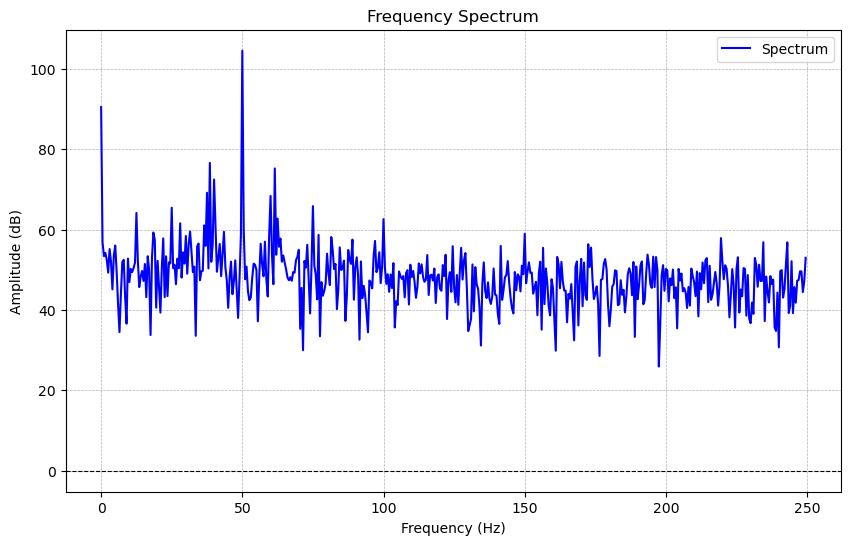

In [10]:
plot_spectrum(pd.read_csv('../data/processed/Normal_and_Candidates_for_Augmentation/Window_1.csv'))

In [11]:
n_candidates = 1500

_ = move_random_csv_files(
    input_dir='../data/processed/Normal_and_Candidates_for_Augmentation',
    output_dir='../data/processed/Candidates_for_Augmentation',
    n_files=n_candidates
)

rename_folder(
    current_folder_path='../data/processed/Normal_and_Candidates_for_Augmentation',
    new_folder_path='../data/processed/Final_Normal'
)

"Folder renamed from '../data/processed/Normal_and_Candidates_for_Augmentation' to '../data/processed/Final_Normal'."

: 